# Compare EDM4hep versions and update reading functions

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("../")
from pyedm4hep import EDM4hepEvent, EDM4hepDataset

## Roadmap

1. Load in both datasets


## Testing

In [13]:
dataset1 = EDM4hepDataset(
    dataset_path="/global/cfs/projectdirs/m4958/data/ColliderML/simulation/pileup-200/gg2ttbar/v1/runs",
    file_pattern="*/edm4hep.root",
    max_files=10, # Optional: limit number of files for testing
    max_events_per_file=10
)

Limiting to first 10 files out of 128 found.


In [14]:
all_particles_df1 = []
all_hits_df1 = []

for event in dataset1:
    all_particles_df1.append(event.get_particles_df())
    all_hits_df1.append(event.get_tracker_hits_df())

all_particles_df1 = pd.concat(all_particles_df1)
all_hits_df1 = pd.concat(all_hits_df1)

Processing file 1/10: edm4hep.root (10 events)...
Loading event 0 from /global/cfs/projectdirs/m4958/data/ColliderML/simulation/pileup-200/gg2ttbar/v1/runs/0/edm4hep.root...
  Loaded 109508 particles.
  Loaded 253919 tracker hits.
  Loaded 1401103 calo hits and 6714348 contributions.
Loading event 1 from /global/cfs/projectdirs/m4958/data/ColliderML/simulation/pileup-200/gg2ttbar/v1/runs/0/edm4hep.root...
  Loaded 99674 particles.
  Loaded 230310 tracker hits.
  Loaded 1302142 calo hits and 6321505 contributions.
Loading event 2 from /global/cfs/projectdirs/m4958/data/ColliderML/simulation/pileup-200/gg2ttbar/v1/runs/0/edm4hep.root...
  Loaded 111590 particles.
  Loaded 256516 tracker hits.
  Loaded 1447110 calo hits and 7014396 contributions.
Loading event 3 from /global/cfs/projectdirs/m4958/data/ColliderML/simulation/pileup-200/gg2ttbar/v1/runs/0/edm4hep.root...
  Loaded 120774 particles.
  Loaded 279837 tracker hits.
  Loaded 1565970 calo hits and 7662572 contributions.
Loading eve

In [15]:
dataset2 = EDM4hepDataset(
    dataset_path="/global/cfs/projectdirs/m4958/data/ColliderML/simulation/pileup-200-new/gg2ttbar/v1/runs",
    file_pattern="*/edm4hep.root",
    max_files=10, # Optional: limit number of files for testing
    max_events_per_file=10
)

Limiting to first 10 files out of 128 found.


In [16]:
all_particles_df2 = []
all_hits_df2 = []

for event in dataset2:
    all_particles_df2.append(event.get_particles_df())
    all_hits_df2.append(event.get_tracker_hits_df())

all_particles_df2 = pd.concat(all_particles_df2)
all_hits_df2 = pd.concat(all_hits_df2)

Processing file 1/10: edm4hep.root (10 events)...
Loading event 0 from /global/cfs/projectdirs/m4958/data/ColliderML/simulation/pileup-200-new/gg2ttbar/v1/runs/0/edm4hep.root...
  Loaded 103236 particles.
  Loaded 235637 tracker hits.
  Loaded 1281646 calo hits and 6151478 contributions.
Loading event 1 from /global/cfs/projectdirs/m4958/data/ColliderML/simulation/pileup-200-new/gg2ttbar/v1/runs/0/edm4hep.root...
  Loaded 110526 particles.
  Loaded 254765 tracker hits.
  Loaded 1392348 calo hits and 6643259 contributions.
Loading event 2 from /global/cfs/projectdirs/m4958/data/ColliderML/simulation/pileup-200-new/gg2ttbar/v1/runs/0/edm4hep.root...
  Loaded 88094 particles.
  Loaded 208760 tracker hits.
  Loaded 1104419 calo hits and 5132178 contributions.
Loading event 3 from /global/cfs/projectdirs/m4958/data/ColliderML/simulation/pileup-200-new/gg2ttbar/v1/runs/0/edm4hep.root...
  Loaded 94459 particles.
  Loaded 221118 tracker hits.
  Loaded 1195170 calo hits and 5615524 contributio

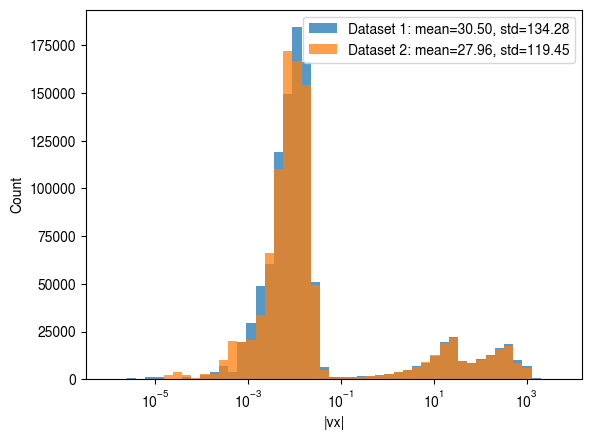

In [9]:
# Plot histogram with log-spaced bins of absolute vx values
log_bins = np.logspace(np.log10(0.000001), np.log10(5000))
vx_abs1 = np.abs(all_particles_df1["vx"])
vx_abs2 = np.abs(all_particles_df2["vx"])
mean1, std1 = vx_abs1.mean(), vx_abs1.std()
mean2, std2 = vx_abs2.mean(), vx_abs2.std()

sns.histplot(vx_abs1, bins=log_bins, label=f'Dataset 1: mean={mean1:.2f}, std={std1:.2f}')
sns.histplot(vx_abs2, bins=log_bins, label=f'Dataset 2: mean={mean2:.2f}, std={std2:.2f}')
plt.xscale('log')
plt.xlabel('|vx|')
plt.legend()

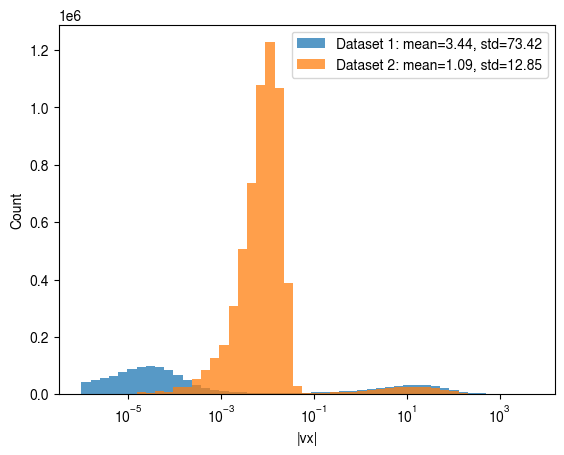

In [ ]:
# Plot histogram with log-spaced bins of absolute vx values
log_bins = np.logspace(np.log10(0.000001), np.log10(5000))
vx_abs1 = np.abs(all_particles_df1[~all_particles_df1.created_in_simulation]["vx"])
vx_abs2 = np.abs(all_particles_df2[~all_particles_df2.created_in_simulation]["vx"])
mean1, std1 = vx_abs1.mean(), vx_abs1.std()
mean2, std2 = vx_abs2.mean(), vx_abs2.std()

sns.histplot(vx_abs1, bins=log_bins, label=f'Dataset 1: mean={mean1:.2f}, std={std1:.2f}')
sns.histplot(vx_abs2, bins=log_bins, label=f'Dataset 2: mean={mean2:.2f}, std={std2:.2f}')
plt.xscale('log')
plt.xlabel('|vx|')
plt.legend()

/tmp/ipykernel_1781617/2479958213.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


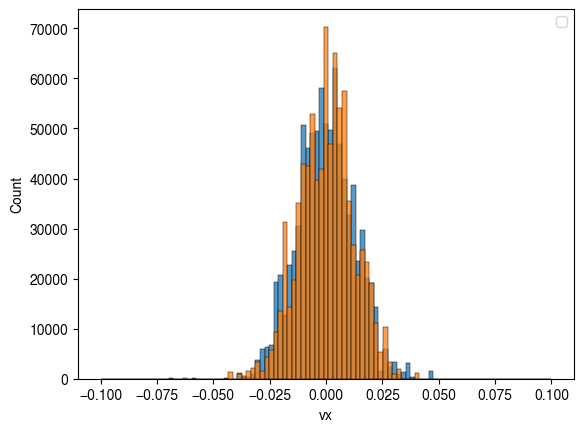

In [10]:
# Plot histogram with log-spaced bins of absolute vx values
lin_bins = np.linspace(-0.1, 0.1, 100)
sns.histplot(all_particles_df1[~all_particles_df1.created_in_simulation]["vx"], bins=lin_bins)
sns.histplot(all_particles_df2[~all_particles_df2.created_in_simulation]["vx"], bins=lin_bins)
plt.xlabel('vx')
plt.legend()

In [ ]:
all_particles_df1.columns

In [18]:
all_particles_df1

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,eta,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,44.085589,0.000000,0.000000,0.015918,7000.000000,6999.061730,0,False,False,False
1,21,61,0,0.000000,0.727745,0.000000,0.015829,0.001684,-61.091192,0.836010,...,7.624277,-1.101549,0.015918,0.015918,1892.423427,1892.423427,0,False,False,False
2,21,61,0,0.000000,0.727745,0.000000,0.015829,0.001684,-61.091192,-1.886406,...,7.798309,-2.441041,0.015918,0.015918,3006.063790,3006.063790,0,False,False,False
3,1,61,0,-0.333333,0.727745,0.000000,0.015829,0.001684,-61.091192,-1.013275,...,4.984224,-3.045689,0.015918,0.015918,74.359927,74.359927,0,False,False,False
4,-2,61,0,-0.666667,0.727745,0.000000,0.015829,0.001684,-61.091192,-1.830228,...,6.213257,3.046482,0.015918,0.015918,459.015834,459.015834,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109497,2112,0,2013265920,0.000000,18.189236,0.939565,-1231.433413,-638.904905,831.844525,0.067051,...,0.433456,0.041222,1387.309528,380.000000,0.942437,0.002871,1,True,False,False
109498,2112,0,2013265920,0.000000,18.271311,0.939565,-1336.968320,-99.898467,323.066949,-0.005259,...,-0.369021,-1.711161,1340.695340,1010.000000,0.940424,0.000859,1,True,False,False
109499,211,0,1157627904,1.000000,14.026149,0.139570,-498.450147,-42.447047,111.131060,-4.976715,...,0.398165,-3.033960,500.254237,1815.927373,5.409541,5.269971,424,True,False,False
109500,11,0,1157627904,-1.000000,16.384525,0.000511,-1170.019955,-114.044043,322.251697,-1.191845,...,0.327520,-3.043240,1175.564859,1267.295318,1.262444,1.261933,571,True,False,False


In [21]:
len(all_particles_df1[all_particles_df1.created_in_simulation]), len(all_particles_df2[all_particles_df2.created_in_simulation])

(1413771, 1345701)

In [22]:
len(all_particles_df1[~all_particles_df1.created_in_simulation]), len(all_particles_df2[~all_particles_df2.created_in_simulation])

(8829015, 8593224)

In [19]:
all_particles_df2

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,eta,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker
0,2212,4,0,1.000000,0.000000,0.93827,0.000000,0.000000,0.000000,0.000000,...,44.085589,0.000000,0.000000,0.017350,7000.000000,6999.061730,0,False,False,False
1,2,61,0,0.666667,-0.172501,0.00000,0.001687,-0.017267,-116.936426,0.123090,...,7.665388,1.524617,0.017350,0.017350,2844.029586,2844.029586,0,False,False,False
2,-2,61,0,-0.666667,-0.172501,0.00000,0.001687,-0.017267,-116.936426,-2.443927,...,0.088904,-2.922529,0.017350,0.017350,2.513666,2.513666,0,False,False,False
3,21,61,0,0.000000,-0.172501,0.00000,0.001687,-0.017267,-116.936426,2.900534,...,0.948880,-0.528995,0.017350,0.017350,4.989232,4.989232,0,False,False,False
4,2103,63,0,0.333333,-0.172501,0.77133,0.001687,-0.017267,-116.936426,-0.156629,...,10.102329,-2.061777,0.017350,0.017350,4052.799522,4052.028192,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90293,22,0,1157627904,0.000000,7.254748,0.00000,23.279638,-5.223938,1935.559168,0.199444,...,2.568069,-0.027249,23.858564,362.788310,1.308572,1.308572,98,True,False,False
90294,22,0,1107296256,0.000000,7.254749,0.00000,23.279639,-5.223934,1935.559269,0.155382,...,3.803141,0.329352,23.858564,380.406402,3.683512,3.683512,0,True,False,False
90295,211,0,1157627904,1.000000,7.268071,0.13957,23.606708,-5.451379,1939.528652,0.311701,...,2.532014,-0.820914,24.227963,399.843217,2.897941,2.758371,310,True,False,False
90296,22,0,1107296256,0.000000,7.254749,0.00000,23.279624,-5.223943,1935.559232,-0.383853,...,3.387314,-2.426308,23.858551,531.968009,7.530607,7.530607,0,True,False,False


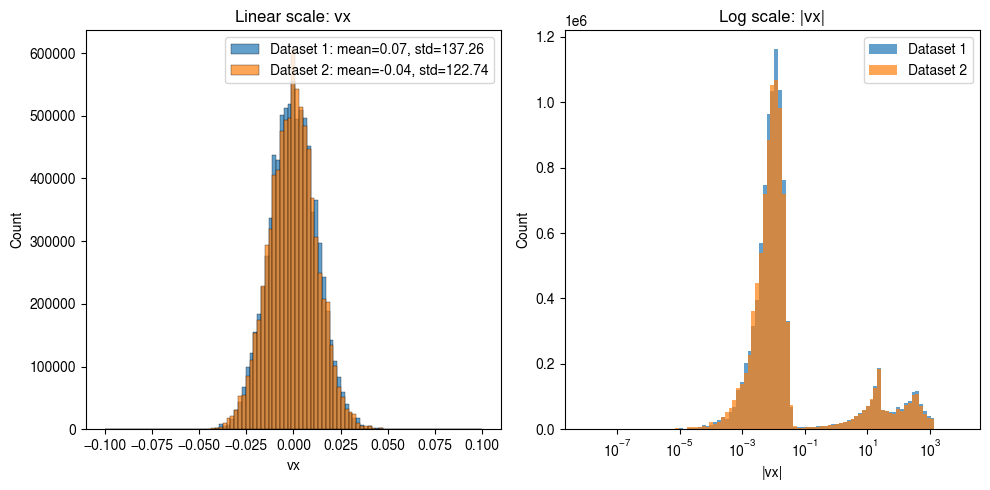

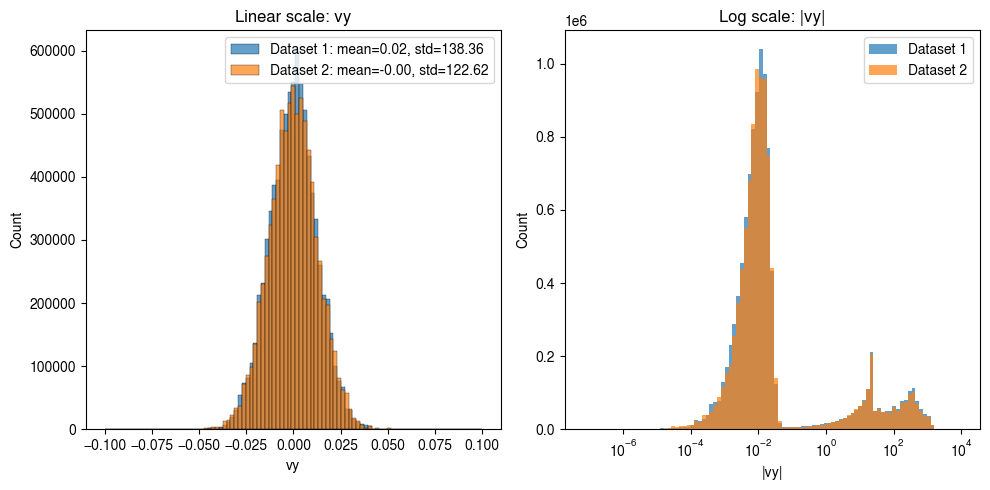

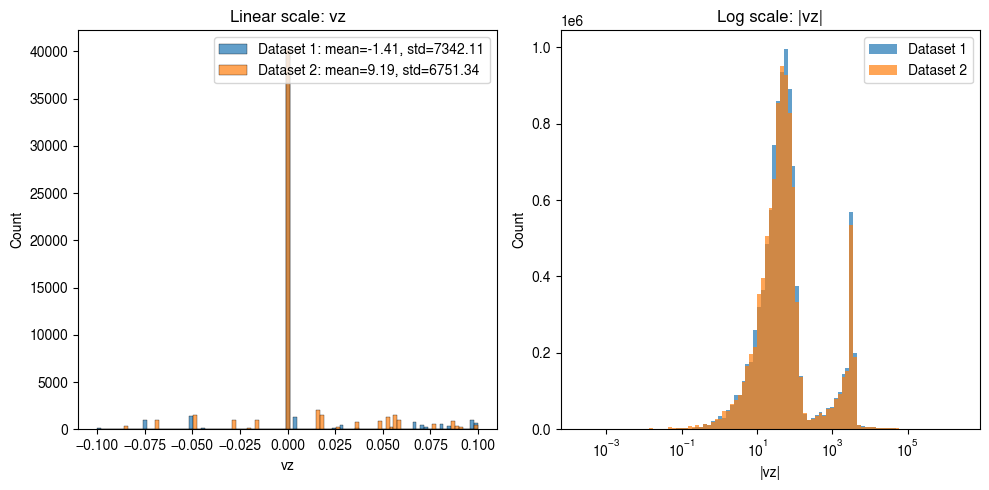

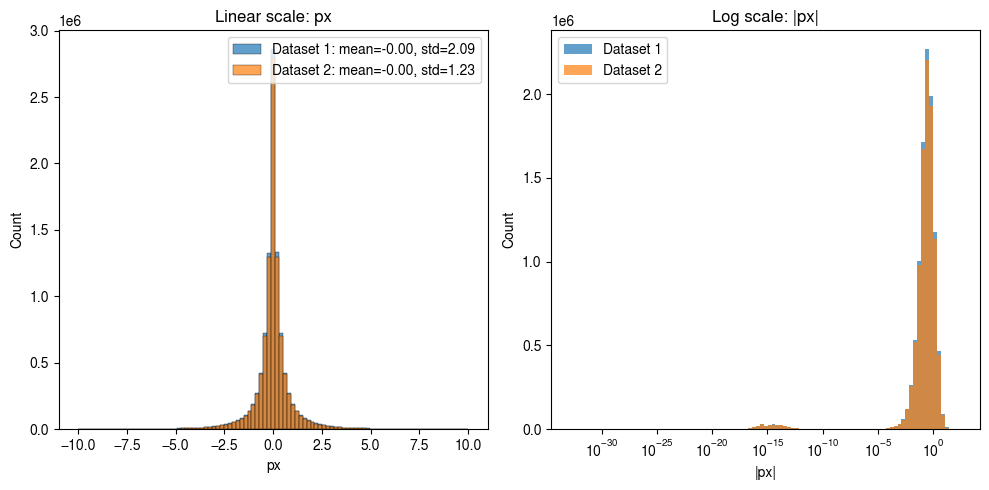

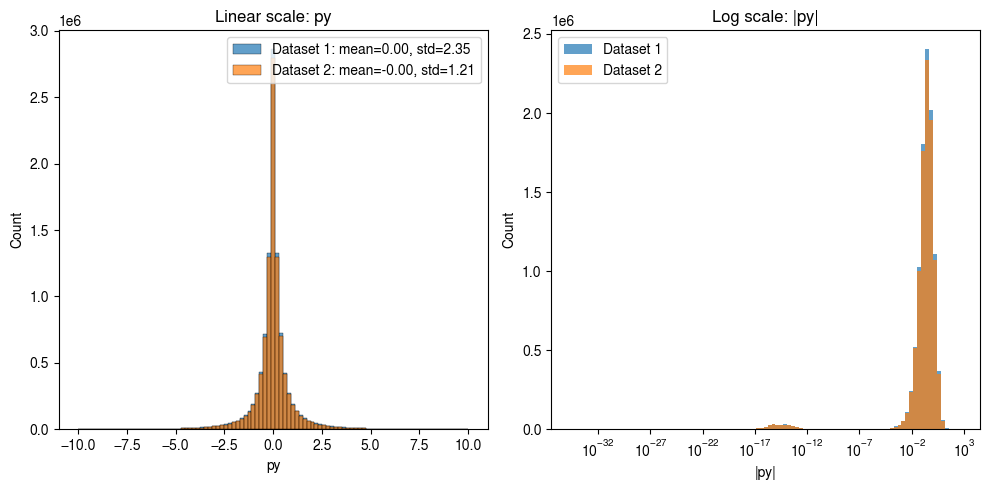

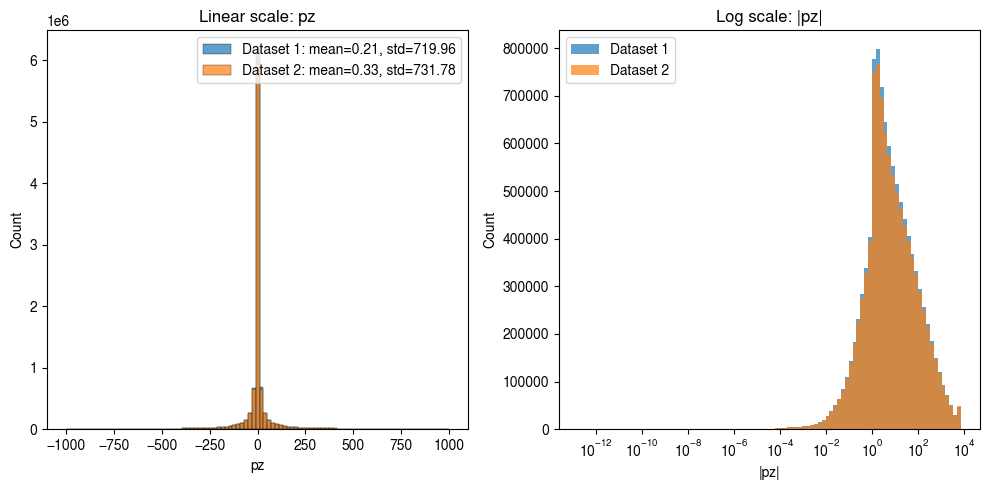

: 

In [23]:
def compare_all_features(df1, df2, features=None, ranges=None, filter_created=False):
    """
    Compare distributions of features between two dataframes with both linear and log plots.
    
    Args:
        df1: First dataframe
        df2: Second dataframe
        features: List of features to compare (default: use all columns)
        ranges: Dict of {feature: (min, max)} for custom ranges
        filter_created: If True, filter out particles created in simulation
    """
    if features is None:
        features = df1.columns
    
    if ranges is None:
        ranges = {}
    
    for feature in features:
        if feature not in df1.columns or feature not in df2.columns:
            print(f"Feature {feature} not found in both dataframes, skipping")
            continue
            
        # Apply filter if requested
        df1_filtered = df1[~df1.created_in_simulation] if filter_created and 'created_in_simulation' in df1.columns else df1
        df2_filtered = df2[~df2.created_in_simulation] if filter_created and 'created_in_simulation' in df2.columns else df2
        
        # Get data
        data1 = df1_filtered[feature]
        data2 = df2_filtered[feature]
        
        # Calculate statistics
        mean1, std1 = data1.mean(), data1.std()
        mean2, std2 = data2.mean(), data2.std()
        
        # Linear plot
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        
        # Use custom range if provided
        if feature in ranges:
            min_val, max_val = ranges[feature]
            bins = np.linspace(min_val, max_val, 100)
        else:
            # Auto range based on data
            min_val = min(data1.min(), data2.min())
            max_val = max(data1.max(), data2.max())
            bins = np.linspace(min_val, max_val, 100)
            
        sns.histplot(data1, bins=bins, label=f'Dataset 1: mean={mean1:.2f}, std={std1:.2f}', alpha=0.7)
        sns.histplot(data2, bins=bins, label=f'Dataset 2: mean={mean2:.2f}, std={std2:.2f}', alpha=0.7)
        plt.xlabel(feature)
        plt.title(f'Linear scale: {feature}')
        plt.legend()
        
        # Log plot (only for features that make sense with log scale)
        plt.subplot(1, 2, 2)
        
        # For position/momentum features, use absolute values for log plot
        if feature in ['vx', 'vy', 'vz', 'px', 'py', 'pz']:
            data1_abs = np.abs(data1)
            data2_abs = np.abs(data2)
            
            # Skip if all zeros
            if data1_abs.min() <= 0 or data2_abs.min() <= 0:
                min_positive = max(data1_abs[data1_abs > 0].min() if any(data1_abs > 0) else 1e-6, 
                                  data2_abs[data2_abs > 0].min() if any(data2_abs > 0) else 1e-6)
            else:
                min_positive = min(data1_abs.min(), data2_abs.min())
                
            max_val = max(data1_abs.max(), data2_abs.max())
            log_bins = np.logspace(np.log10(min_positive), np.log10(max_val), 100)
            
            sns.histplot(data1_abs, bins=log_bins, label=f'Dataset 1', alpha=0.7)
            sns.histplot(data2_abs, bins=log_bins, label=f'Dataset 2', alpha=0.7)
            plt.xscale('log')
            plt.xlabel(f'|{feature}|')
            plt.title(f'Log scale: |{feature}|')
            plt.legend()
        else:
            plt.text(0.5, 0.5, 'Log scale not applicable', 
                     horizontalalignment='center', verticalalignment='center')
            
        plt.tight_layout()
        plt.show()

# Compare the specified features
features_to_compare = ["vx", "vy", "vz", "px", "py", "pz"]
ranges = {
    "vx": (-0.1, 0.1),
    "vy": (-0.1, 0.1),
    "vz": (-0.1, 0.1),
    "px": (-10, 10),
    "py": (-10, 10),
    "pz": (-1000, 1000)
}
compare_all_features(all_particles_df1, all_particles_df2, features=features_to_compare, ranges=ranges)